## Lab: RNN with Forecasting

### Wind Turbine Power Prediction with RNN

This lab uses a Recurrent Neural Network to predict wind turbine power output.
* [Data link](https://www.kaggle.com/code/ahmedfathygwely/wind-turbine-dataset-machine-learning-rnn-times/input)

### Step 0: Load libraries & Data

In [ ]:
# Step 0: Load libraries & Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import math

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load the data
df = pd.read_csv('T1.csv.zip')

In [ ]:
# Display basic information

print(df.shape)
df.head()
df.info()
df.describe()

(50530, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


### Step 1: Prepare the data

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64


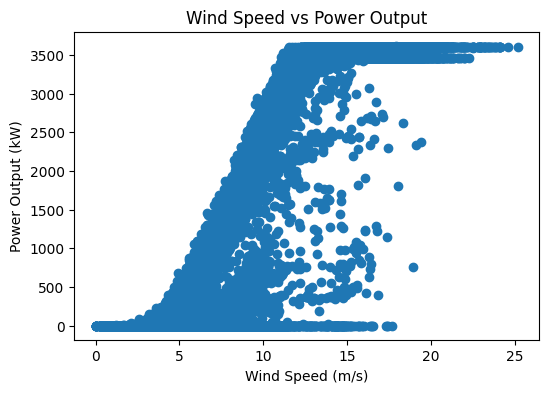

(50530, 3)


In [ ]:
# Step 1: Prepare the data
df['Date/Time'] = pd.to_datetime(df['Date/Time'], format='%d %m %Y %H:%M')
print(df.isnull().sum())
df.describe()

plt.figure(figsize=(6,4))
plt.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'])
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kW)')
plt.title('Wind Speed vs Power Output')
plt.show()

data = df[['LV ActivePower (kW)',
           'Wind Speed (m/s)',
           'Theoretical_Power_Curve (KWh)']]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

print(scaled_data.shape)

### Step 2: Create sequences

In [ ]:
# Step 2: Create sequences

def create_sequences(data, seq_length):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])     # past window
        y.append(data[i+seq_length][0])    # predict power (first column)

    return np.array(X), np.array(y)

seq_length = 24  # use past 24 time steps

X, y = create_sequences(scaled_data, seq_length)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50506, 24, 3)
y shape: (50506,)


### Step 3: Split the data

In [ ]:
# Step 3: Split the data

train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

### Step 4: Build the RNN Model

In [ ]:
# Step 4: Build the RNN Model

model = Sequential()

# First LSTM layer (returns sequences for stacking)
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Second LSTM layer
model.add(LSTM(32))
model.add(Dropout(0.2))

# Final prediction layer (single value: power output)
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

### Step 5: Train the model

Epoch 1/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0132 - val_loss: 0.0051
Epoch 2/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - loss: 0.0077 - val_loss: 0.0053
Epoch 3/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - loss: 0.0069 - val_loss: 0.0052
Epoch 4/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - loss: 0.0065 - val_loss: 0.0044
Epoch 5/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0064 - val_loss: 0.0044
Epoch 6/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - loss: 0.0062 - val_loss: 0.0044
Epoch 7/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - loss: 0.0062 - val_loss: 0.0045
Epoch 8/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0061 - val_loss: 0.0041
Epoch 9/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0061 - val_loss: 0.0048
Epoch 10/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 0.0061 - val_loss: 0.0042
Epoch 11/30
1011/1011 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - loss: 0.0060 - val_loss: 0.0046
Epoch 12

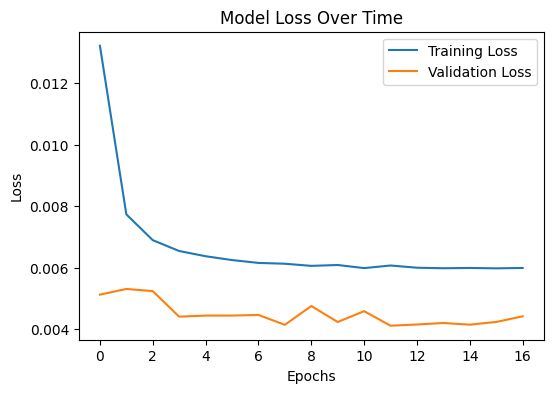

In [ ]:
# Step 5: Train the model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Step 6: Evaluate on the test data and visualize the results

316/316 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
RMSE: 226.6418293114201
R² Score: 0.9714780682179599


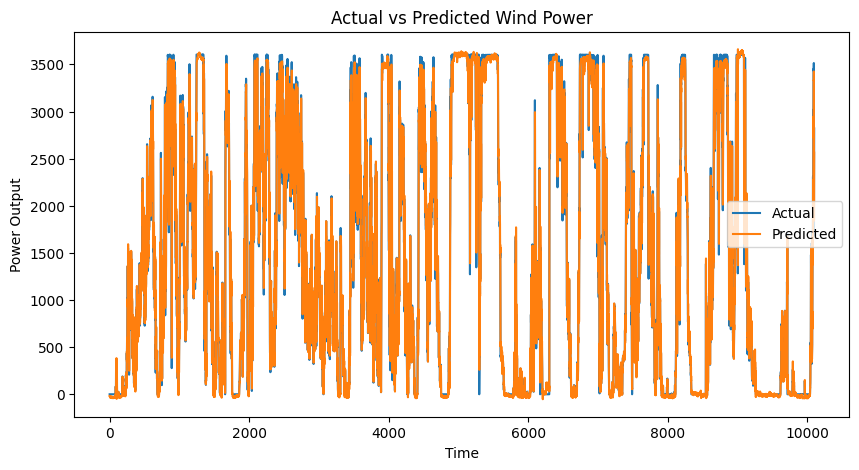

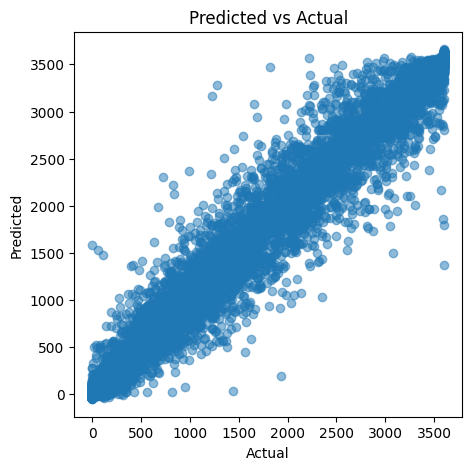

In [ ]:
# Step 6: Evaluate and visualize

y_pred = model.predict(X_test)

y_test_reshaped = y_test.reshape(-1, 1)
y_pred_reshaped = y_pred.reshape(-1, 1)

y_test_inv = scaler.inverse_transform(
    np.concatenate([y_test_reshaped, np.zeros((len(y_test), 2))], axis=1)
)[:, 0]

y_pred_inv = scaler.inverse_transform(
    np.concatenate([y_pred_reshaped, np.zeros((len(y_pred), 2))], axis=1)
)[:, 0]

rmse = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
r2 = r2_score(y_test_inv, y_pred_inv)

print("RMSE:", rmse)
print("R² Score:", r2)

plt.figure(figsize=(10,5))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_inv, label='Predicted')
plt.title('Actual vs Predicted Wind Power')
plt.xlabel('Time')
plt.ylabel('Power Output')
plt.legend()
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.5)
plt.title('Predicted vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

/tmp/ipykernel_2530/4282473714.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_error = df.groupby('wind_bin')['error'].mean()


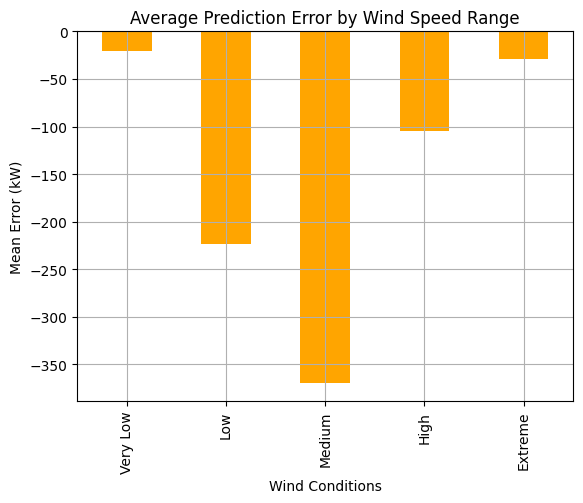

In [18]:
actual_col = "LV ActivePower (kW)"
pred_col = "Theoretical_Power_Curve (KWh)"
wind_col = "Wind Speed (m/s)"

# Compute error
df['error'] = df[actual_col] - df[pred_col]

# Bin wind speed
df['wind_bin'] = pd.cut(df[wind_col],
                        bins=[0,5,10,15,20,30],
                        labels=['Very Low','Low','Medium','High','Extreme'])

# Average error per wind condition
avg_error = df.groupby('wind_bin')['error'].mean()

# Plot
avg_error.plot(kind='bar', color='orange')
plt.title("Average Prediction Error by Wind Speed Range")
plt.ylabel("Mean Error (kW)")
plt.xlabel("Wind Conditions")
plt.grid(True)
plt.show()